# Kenya Land Readiness Atlas: baseline notebook

Run top to bottom on Colab (CPU runtime is enough, no GPU needed).

What it does: pulls Sentinel-2 features and WorldCover labels for 4 contrasting regions through Earth Engine, caches them to Drive, builds buffered spatial-block folds, trains a shallow decision tree and a LightGBM baseline, evaluates with spatial CV and leave-one-region-out, and reports a confusion matrix, prevalence-weighted accuracy and calibration.

Before running: set PROJECT in the config cell to your Google Cloud project that is registered for Earth Engine.

## 1. Install

In [ ]:
!pip -q install -U earthengine-api lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 482.1/482.1 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.5/263.5 kB 15.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.59.1 which is incompatible.
google-genai 2.12.1 requires google-auth[requests]<2.56.0,>=2.48.1, but you have google-auth 2.59.1 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.2 which is incompatible.


## 2. Config

In [ ]:
PROJECT = "propertysatellite"   # <-- set this

YEAR = 2021               # WorldCover v200 is a 2021 map, so use 2021 imagery
PER_CLASS = 400           # target samples per class per region (stratified)
CLOUD_THRESH = 0.6        # Cloud Score+ cs_cdf threshold
BLOCK_DEG = 0.05          # spatial block size in degrees (about 5.5 km)
N_FOLDS = 5
SEED = 42
USE_DRIVE = True
OUT_DIR = "/content/drive/MyDrive/land_atlas_baseline" if USE_DRIVE else "/content/land_atlas_baseline"

CLASSES = ["built_up", "cropland", "trees", "grass_shrub", "water", "bare"]

# [min_lon, min_lat, max_lon, max_lat]
REGIONS = {
    "highland":   [36.30, -0.60, 36.80, -0.10],
    "coast":      [39.40, -3.90, 39.90, -3.40],
    "arid":       [37.50,  1.50, 38.00,  2.00],
    "lake_basin": [34.60, -0.30, 35.10,  0.20],
}

## 3. Earth Engine and Drive

In [ ]:
import os, ee
assert PROJECT != "your-gcp-project-id", "Set PROJECT in the config cell first."
try:
    ee.Initialize(project=PROJECT)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=PROJECT)
print("Earth Engine ready")

if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
os.makedirs(OUT_DIR, exist_ok=True)
CACHE = f"{OUT_DIR}/samples_{YEAR}_n{PER_CLASS}.csv"
print("Cache:", CACHE, "| exists:", os.path.exists(CACHE))

Earth Engine ready
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cache: /content/drive/MyDrive/land_atlas_baseline/samples_2021_n400.csv | exists: True


## 4. Data: Sentinel-2 features and WorldCover labels

Labels are WorldCover 2021 remapped to 6 classes (wetland to water, mangrove to trees, snow and moss dropped). This measures agreement with WorldCover, not ground truth. The independent hand-labelled test set comes later.

In [ ]:
import os, time, json
import numpy as np, pandas as pd

BANDS = ["B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B11", "B12"]
IDX = ["NDVI", "NDWI", "MNDWI", "NDBI"]
EXTRA = ["NDVI_p10", "NDVI_p90", "NDVI_stdDev", "elev", "slope"]
FEATURES = BANDS + IDX + EXTRA
K = len(CLASSES)

CHUNK_DIR = f"{OUT_DIR}/chunks_{YEAR}_n{PER_CLASS}"
os.makedirs(CHUNK_DIR, exist_ok=True)
print(f"Chunk directory ready: {CHUNK_DIR}")

def retry(fn, tries=3, wait=10):
    for i in range(tries):
        try:
            return fn()
        except Exception as e:
            print(f"  retry {i+1}/{tries}: {str(e)[:120]}")
            time.sleep(wait)
    return fn()

def label_image():
    wc = ee.ImageCollection("ESA/WorldCover/v200").first().select("Map")
    # built 0, crop 1, trees 2, grass/shrub 3, water 4, bare 5
    return wc.remap([10, 20, 30, 40, 50, 60, 80, 90, 95],
                    [2, 3, 3, 1, 0, 5, 4, 4, 2]).rename("label").toInt()

def feature_image(geom):
    csp = ee.ImageCollection("GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED")
    s2 = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
          .filterDate(f"{YEAR}-01-01", f"{YEAR+1}-01-01")
          .filterBounds(geom)
          .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 30))
          .linkCollection(csp, ["cs_cdf"])
          .map(lambda im: im.updateMask(im.select("cs_cdf").gte(CLOUD_THRESH))))

    def add_idx(im):
        im = im.select(BANDS).divide(10000)
        ndvi = im.normalizedDifference(["B8", "B4"]).rename("NDVI")
        ndwi = im.normalizedDifference(["B3", "B8"]).rename("NDWI")
        mndwi = im.normalizedDifference(["B3", "B11"]).rename("MNDWI")
        ndbi = im.normalizedDifference(["B11", "B8"]).rename("NDBI")
        return im.addBands([ndvi, ndwi, mndwi, ndbi])

    col = s2.map(add_idx)
    med = col.select(BANDS + IDX).median()
    ndvi_stats = col.select("NDVI").reduce(
        ee.Reducer.minMax().combine(ee.Reducer.stdDev(), sharedInputs=True)
    ).rename(["NDVI_p10", "NDVI_p90", "NDVI_stdDev"])
    elev = ee.Image("USGS/SRTMGL1_003").rename("elev")
    slope = ee.Terrain.slope(ee.Image("USGS/SRTMGL1_003")).rename("slope")
    return med.addBands(ndvi_stats).addBands(elev).addBands(slope).select(FEATURES)

def get_sub_bboxes(bbox, n_split=4):
    min_x, min_y, max_x, max_y = bbox
    xs = np.linspace(min_x, max_x, n_split + 1)
    ys = np.linspace(min_y, max_y, n_split + 1)
    boxes = []
    for i in range(n_split):
        for j in range(n_split):
            boxes.append([xs[i], ys[j], xs[i+1], ys[j+1]])
    return boxes

def pull_sub_tile(name, sub_idx, total_subs, sub_bbox, points_per_class):
    chunk_path = os.path.join(CHUNK_DIR, f"chunk_{name}_sub{sub_idx}.csv")
    if os.path.exists(chunk_path):
        d_cached = pd.read_csv(chunk_path)
        print(f"  [Cache hit] {name} sub-tile {sub_idx+1}/{total_subs} ({len(d_cached)} rows)")
        return d_cached

    t0 = time.time()
    print(f"  Sampling {name} sub-tile {sub_idx+1}/{total_subs} ...")
    geom = ee.Geometry.Rectangle(sub_bbox)
    img = feature_image(geom).addBands(label_image())

    fc = img.stratifiedSample(
        numPoints=0, classBand="label", region=geom, scale=10, seed=SEED + sub_idx,
        classValues=list(range(K)), classPoints=[points_per_class] * K,
        dropNulls=True, tileScale=16, geometries=True)
    feats = retry(lambda: fc.getInfo())["features"]
    rows = [{**f["properties"],
             "lon": f["geometry"]["coordinates"][0],
             "lat": f["geometry"]["coordinates"][1]} for f in feats]
    d = pd.DataFrame(rows)
    d["region"] = name
    d["sub_idx"] = sub_idx
    d.to_csv(chunk_path, index=False)
    print(f"    -> Saved chunk: {chunk_path} ({len(d)} points in {time.time()-t0:.1f}s)")
    return d

def pull_region(name, bbox, n_split=4):
    sub_bboxes = get_sub_bboxes(bbox, n_split=n_split)
    total_subs = len(sub_bboxes)
    pts_per_sub = max(5, PER_CLASS // total_subs)

    parts = []
    for sub_i, sub_b in enumerate(sub_bboxes):
        sub_df = pull_sub_tile(name, sub_i, total_subs, sub_b, pts_per_sub)
        parts.append(sub_df)
    d = pd.concat(parts, ignore_index=True)

    # Cached WorldCover class frequency histogram
    hist_path = os.path.join(CHUNK_DIR, f"hist_{name}.json")
    if os.path.exists(hist_path):
        with open(hist_path, "r") as f:
            share = {int(k): v for k, v in json.load(f).items()}
    else:
        geom = ee.Geometry.Rectangle(bbox)
        hist = retry(lambda: label_image().reduceRegion(
            reducer=ee.Reducer.frequencyHistogram(), geometry=geom, scale=100,
            maxPixels=int(1e10), bestEffort=True, tileScale=16).get("label").getInfo())
        share = {int(float(k)): v for k, v in hist.items()}
        with open(hist_path, "w") as f:
            json.dump(share, f)

    n = d["label"].value_counts().to_dict()
    present = {c: share.get(c, 0) for c in n}
    tot = sum(present.values())
    d["weight"] = d["label"].map(lambda c: (present[c] / tot) / n[c] if tot > 0 and n.get(c, 0) > 0 else 1.0)
    return d

if os.path.exists(CACHE):
    df = pd.read_csv(CACHE)
    print("Loaded main cache:", df.shape)
else:
    parts = []
    for name, bbox in REGIONS.items():
        t0 = time.time()
        print(f"--- Sampling region: {name} ---")
        parts.append(pull_region(name, bbox))
        print(f"Done {name}: {len(parts[-1])} total points in {time.time()-t0:.0f}s\n")
    df = pd.concat(parts, ignore_index=True)
    df.to_csv(CACHE, index=False)
    print("Saved combined cache to Drive:", CACHE)

df = df.dropna(subset=FEATURES + ["label"]).reset_index(drop=True)
df["label"] = df["label"].astype(int)
print("Final Dataset Shape:", df.shape)
display(pd.crosstab(df["region"], df["label"].map(dict(enumerate(CLASSES)))))


Chunk directory ready: /content/drive/MyDrive/land_atlas_baseline/chunks_2021_n400
--- Sampling region: highland ---
  Sampling highland sub-tile 1/16 ...
    -> Saved chunk: /content/drive/MyDrive/land_atlas_baseline/chunks_2021_n400/chunk_highland_sub0.csv (150 points in 60.0s)
  Sampling highland sub-tile 2/16 ...
    -> Saved chunk: /content/drive/MyDrive/land_atlas_baseline/chunks_2021_n400/chunk_highland_sub1.csv (150 points in 71.1s)
  Sampling highland sub-tile 3/16 ...
    -> Saved chunk: /content/drive/MyDrive/land_atlas_baseline/chunks_2021_n400/chunk_highland_sub2.csv (150 points in 73.3s)
  Sampling highland sub-tile 4/16 ...
    -> Saved chunk: /content/drive/MyDrive/land_atlas_baseline/chunks_2021_n400/chunk_highland_sub3.csv (150 points in 103.6s)
  Sampling highland sub-tile 5/16 ...
    -> Saved chunk: /content/drive/MyDrive/land_atlas_baseline/chunks_2021_n400/chunk_highland_sub4.csv (150 points in 88.3s)
  Sampling highland sub-tile 6/16 ...
    -> Saved chunk: /con

    -> Saved chunk: /content/drive/MyDrive/land_atlas_baseline/chunks_2021_n400/chunk_coast_sub7.csv (150 points in 220.7s)
  Sampling coast sub-tile 9/16 ...


    -> Saved chunk: /content/drive/MyDrive/land_atlas_baseline/chunks_2021_n400/chunk_coast_sub8.csv (150 points in 23.1s)
  Sampling coast sub-tile 10/16 ...
    -> Saved chunk: /content/drive/MyDrive/land_atlas_baseline/chunks_2021_n400/chunk_coast_sub9.csv (150 points in 28.8s)
  Sampling coast sub-tile 11/16 ...
    -> Saved chunk: /content/drive/MyDrive/land_atlas_baseline/chunks_2021_n400/chunk_coast_sub10.csv (150 points in 72.8s)
  Sampling coast sub-tile 12/16 ...
    -> Saved chunk: /content/drive/MyDrive/land_atlas_baseline/chunks_2021_n400/chunk_coast_sub11.csv (150 points in 23.4s)
  Sampling coast sub-tile 13/16 ...
    -> Saved chunk: /content/drive/MyDrive/land_atlas_baseline/chunks_2021_n400/chunk_coast_sub12.csv (150 points in 56.1s)
  Sampling coast sub-tile 14/16 ...
    -> Saved chunk: /content/drive/MyDrive/land_atlas_baseline/chunks_2021_n400/chunk_coast_sub13.csv (150 points in 75.5s)
  Sampling coast sub-tile 15/16 ...
    -> Saved chunk: /content/drive/MyDrive

    -> Saved chunk: /content/drive/MyDrive/land_atlas_baseline/chunks_2021_n400/chunk_lake_basin_sub4.csv (150 points in 154.5s)
  Sampling lake_basin sub-tile 6/16 ...
    -> Saved chunk: /content/drive/MyDrive/land_atlas_baseline/chunks_2021_n400/chunk_lake_basin_sub5.csv (150 points in 100.6s)
  Sampling lake_basin sub-tile 7/16 ...
    -> Saved chunk: /content/drive/MyDrive/land_atlas_baseline/chunks_2021_n400/chunk_lake_basin_sub6.csv (150 points in 39.6s)
  Sampling lake_basin sub-tile 8/16 ...
    -> Saved chunk: /content/drive/MyDrive/land_atlas_baseline/chunks_2021_n400/chunk_lake_basin_sub7.csv (150 points in 31.5s)
  Sampling lake_basin sub-tile 9/16 ...
    -> Saved chunk: /content/drive/MyDrive/land_atlas_baseline/chunks_2021_n400/chunk_lake_basin_sub8.csv (150 points in 176.9s)
  Sampling lake_basin sub-tile 10/16 ...
    -> Saved chunk: /content/drive/MyDrive/land_atlas_baseline/chunks_2021_n400/chunk_lake_basin_sub9.csv (150 points in 35.0s)
  Sampling lake_basin sub-ti

label,bare,built_up,cropland,grass_shrub,trees,water
region,,,,,,
arid,400,210,83,400,359,22
coast,400,400,400,400,400,351
highland,347,331,378,400,400,400
lake_basin,375,375,375,375,375,400


## 5. Spatial blocks and buffered folds

Points are grouped into 0.05 degree blocks. Whole blocks go to the test fold, and any training point in a block touching a test block is dropped (buffer), so neighbouring pixels cannot leak across the split.

In [ ]:
from sklearn.model_selection import GroupKFold

df["bx"] = np.floor(df["lon"] / BLOCK_DEG).astype(int)
df["by"] = np.floor(df["lat"] / BLOCK_DEG).astype(int)
df["block"] = df["region"] + "_" + df["bx"].astype(str) + "_" + df["by"].astype(str)
print("Blocks:", df["block"].nunique())

reg, bx, by = df["region"].values, df["bx"].values, df["by"].values

def buffered_train(train_idx, test_idx):
    test_blocks = set(zip(reg[test_idx], bx[test_idx], by[test_idx]))
    keep = []
    for i in train_idx:
        near = any((reg[i], bx[i] + dx, by[i] + dy) in test_blocks
                   for dx in (-1, 0, 1) for dy in (-1, 0, 1))
        if not near:
            keep.append(i)
    return np.array(keep)

gkf = GroupKFold(n_splits=N_FOLDS)
FOLDS = []
for tr, te in gkf.split(df, df["label"], groups=df["block"]):
    tr_b = buffered_train(tr, te)
    FOLDS.append((tr_b, te))
    print(f"fold: train {len(tr)} -> {len(tr_b)} after buffer | test {len(te)}")

Blocks: 400
fold: train 6684 -> 1488 after buffer | test 1672
fold: train 6685 -> 1488 after buffer | test 1671
fold: train 6685 -> 1707 after buffer | test 1671
fold: train 6685 -> 1219 after buffer | test 1671
fold: train 6685 -> 1810 after buffer | test 1671


## 6. Models and metrics helpers

In [ ]:
import lightgbm as lgb
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix

X = df[FEATURES].values
y = df["label"].values
w = df["weight"].values
N = len(df)

LGB_PARAMS = dict(objective="multiclass", n_estimators=300, learning_rate=0.05,
                  num_leaves=31, subsample=0.8, subsample_freq=1,
                  colsample_bytree=0.8, random_state=SEED, n_jobs=-1, verbose=-1)
RULE_FEATS = [FEATURES.index(c) for c in ["NDVI", "NDWI", "MNDWI", "NDBI", "elev"]]

def make_model(name):
    if name == "tree_rule":
        return DecisionTreeClassifier(max_depth=4, random_state=SEED)
    return lgb.LGBMClassifier(**LGB_PARAMS)

def cols(name):
    return RULE_FEATS if name == "tree_rule" else list(range(len(FEATURES)))

def fit_predict(name, tr, te):
    m = make_model(name)
    c = cols(name)
    m.fit(X[tr][:, c], y[tr])
    p = np.zeros((len(te), K))
    p[:, m.classes_] = m.predict_proba(X[te][:, c])
    return m, p

def metrics(y_true, proba, weights):
    pred = proba.argmax(1)
    return dict(acc=float((pred == y_true).mean()),
                weighted_acc=float(np.average(pred == y_true, weights=weights)),
                macro_f1=float(f1_score(y_true, pred, average="macro")))

def ece(proba, y_true, bins=10):
    conf, pred = proba.max(1), proba.argmax(1)
    ok = (pred == y_true).astype(float)
    edges = np.linspace(0, 1, bins + 1)
    out, tot = 0.0, len(y_true)
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.any():
            out += m.sum() / tot * abs(ok[m].mean() - conf[m].mean())
    return float(out)

## 7. Spatial block CV (buffered)

In [ ]:
MODELS = ["tree_rule", "lgbm"]
oof = {m: np.full((N, K), np.nan) for m in MODELS}

for name in MODELS:
    for i, (tr, te) in enumerate(FOLDS):
        _, p = fit_predict(name, tr, te)
        oof[name][te] = p
    print("done", name)

rows = []
for name in MODELS:
    r = metrics(y, oof[name], w)
    r["ece"] = ece(oof[name], y)
    r["model"] = name
    rows.append(r)
cv_table = pd.DataFrame(rows).set_index("model").round(4)
display(cv_table)

done tree_rule
done lgbm


,acc,weighted_acc,macro_f1,ece
model,,,,
tree_rule,0.4444,0.4311,0.4309,0.1008
lgbm,0.6474,0.6496,0.6483,0.2525


## 8. Leave-one-region-out

The harder test: train on 3 regions, test on the 4th. Expect lower numbers than block CV. That gap is the honest generalisation story.

In [ ]:
loro_rows = []
for held in REGIONS:
    te = np.where(df["region"].values == held)[0]
    tr = np.where(df["region"].values != held)[0]
    for name in MODELS:
        _, p = fit_predict(name, tr, te)
        r = metrics(y[te], p, w[te])
        r.update(held_out=held, model=name)
        loro_rows.append(r)
loro = pd.DataFrame(loro_rows).set_index(["held_out", "model"]).round(4)
display(loro)
display(loro.groupby("model").mean().round(4).rename(columns=lambda c: c + " (mean)"))

acc  weighted_acc  macro_f1
held_out   model                                    
highland   tree_rule  0.4579        0.2936    0.4236
           lgbm       0.6525        0.4604    0.6416
coast      tree_rule  0.3713        0.5278    0.3144
           lgbm       0.4326        0.7315    0.4195
arid       tree_rule  0.2198        0.1266    0.1427
           lgbm       0.3107        0.0633    0.1772
lake_basin tree_rule  0.3815        0.4303    0.3486
           lgbm       0.4514        0.5216    0.4231

,acc (mean),weighted_acc (mean),macro_f1 (mean)
model,,,
lgbm,0.4618,0.4442,0.4154
tree_rule,0.3576,0.3446,0.3073


## 9. Confusion matrix, per-region error, calibration

/tmp/ipykernel_1081/1763456838.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .groupby("region").apply(lambda g: np.average(g["ok"], weights=g["w"])))


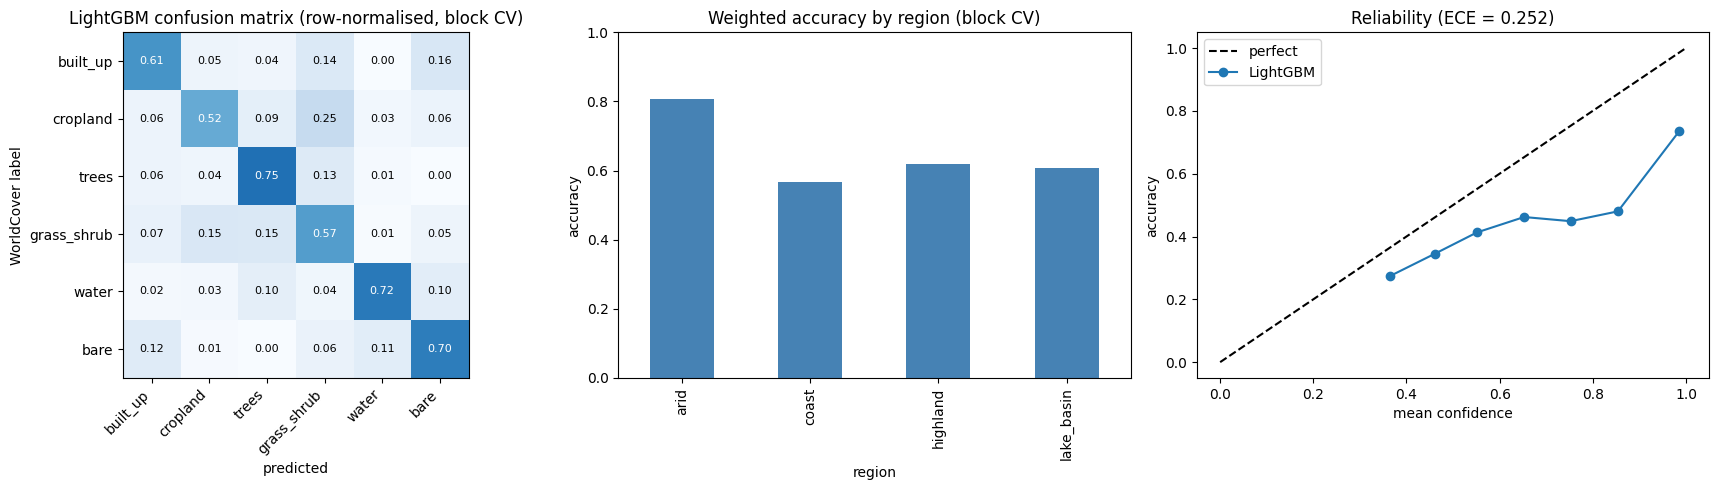

Per-class recall (block CV):
built_up       0.612
cropland       0.515
trees          0.752
grass_shrub    0.574
water          0.719
bare           0.701


In [ ]:
import matplotlib.pyplot as plt

pred = oof["lgbm"].argmax(1)
cm = confusion_matrix(y, pred, labels=range(K), normalize="true")

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

im = ax[0].imshow(cm, vmin=0, vmax=1, cmap="Blues")
ax[0].set_xticks(range(K)); ax[0].set_xticklabels(CLASSES, rotation=45, ha="right")
ax[0].set_yticks(range(K)); ax[0].set_yticklabels(CLASSES)
for i in range(K):
    for j in range(K):
        ax[0].text(j, i, f"{cm[i,j]:.2f}", ha="center", va="center",
                   color="white" if cm[i, j] > 0.5 else "black", fontsize=8)
ax[0].set_title("LightGBM confusion matrix (row-normalised, block CV)")
ax[0].set_xlabel("predicted"); ax[0].set_ylabel("WorldCover label")

reg_acc = (pd.DataFrame({"region": df["region"], "ok": pred == y, "w": w})
           .groupby("region").apply(lambda g: np.average(g["ok"], weights=g["w"])))
reg_acc.plot.bar(ax=ax[1], color="steelblue")
ax[1].set_ylim(0, 1); ax[1].set_title("Weighted accuracy by region (block CV)")
ax[1].set_ylabel("accuracy")

conf = oof["lgbm"].max(1); ok = (pred == y).astype(float)
edges = np.linspace(0, 1, 11); xs, ys = [], []
for lo, hi in zip(edges[:-1], edges[1:]):
    m = (conf > lo) & (conf <= hi)
    if m.sum() >= 10:
        xs.append(conf[m].mean()); ys.append(ok[m].mean())
ax[2].plot([0, 1], [0, 1], "k--", label="perfect")
ax[2].plot(xs, ys, "o-", label="LightGBM")
ax[2].set_xlabel("mean confidence"); ax[2].set_ylabel("accuracy")
ax[2].set_title(f"Reliability (ECE = {ece(oof['lgbm'], y):.3f})"); ax[2].legend()

plt.tight_layout(); plt.show()

print("Per-class recall (block CV):")
print(pd.Series(np.diag(cm), index=CLASSES).round(3).to_string())

## 10. Feature importance and final model

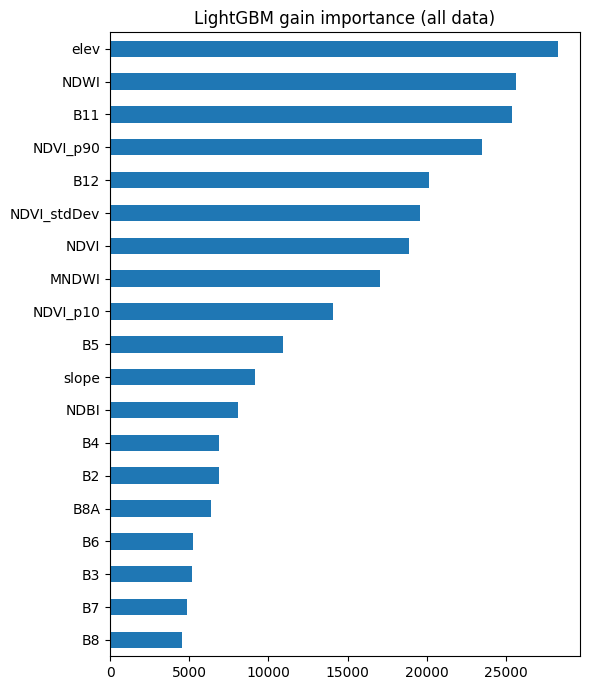

In [ ]:
final = lgb.LGBMClassifier(**LGB_PARAMS).fit(X, y)
imp = pd.Series(final.booster_.feature_importance("gain"), index=FEATURES).sort_values()
imp.plot.barh(figsize=(6, 7), title="LightGBM gain importance (all data)")
plt.tight_layout(); plt.show()

## 11. Save artefacts and summary

In [ ]:
import json, joblib

final.booster_.save_model(f"{OUT_DIR}/lgbm_baseline.txt")
joblib.dump(final, f"{OUT_DIR}/lgbm_baseline.joblib")

oof_df = df[["region", "block", "lon", "lat", "label"]].copy()
oof_df["pred"] = oof["lgbm"].argmax(1)
oof_df["conf"] = oof["lgbm"].max(1)
oof_df.to_csv(f"{OUT_DIR}/oof_predictions.csv", index=False)

summary = dict(
    year=YEAR, per_class=PER_CLASS, n_points=int(N), classes=CLASSES, features=FEATURES,
    block_cv=cv_table.reset_index().to_dict("records"),
    leave_one_region_out=loro.reset_index().to_dict("records"),
)
with open(f"{OUT_DIR}/baseline_results.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Saved to", OUT_DIR)
print("\nBlock CV:")
display(cv_table)
print("Leave-one-region-out mean:")
display(loro.groupby("model").mean().round(4))

Saved to /content/drive/MyDrive/land_atlas_baseline

Block CV:


,acc,weighted_acc,macro_f1,ece
model,,,,
tree_rule,0.4444,0.4311,0.4309,0.1008
lgbm,0.6474,0.6496,0.6483,0.2525


Leave-one-region-out mean:


,acc,weighted_acc,macro_f1
model,,,
lgbm,0.4618,0.4442,0.4154
tree_rule,0.3576,0.3446,0.3073


## Reading these numbers

All accuracy here is agreement with WorldCover, which is itself a model. Weighted accuracy reweights the class-balanced sample by each class's share of the region, so rare classes like built-up do not inflate the headline number. Before you quote any figure, add the independent test: hand-label 300 to 500 stratified random points from high-resolution basemaps and score the model on those with a confusion matrix and area-weighted accuracy (Olofsson et al., 2014).

Next steps from here: swap LightGBM for a ResNet18 or EfficientNet-B0 fine-tune on 64x64 patches, track runs in MLflow, then export the best model to ONNX for CPU serving.

In [ ]:
import os

from google.colab import drive
drive.mount('/content/drive')

if not os.path.exists('/content/Satellite'):
    !git clone https://github.com/VAL-Jerono/Satellite.git /content/Satellite

%cd /content/Satellite
!git pull

!pip install -q -r requirements.txt opencv-python-headless

!python -m data.pipeline.patch_export --project propertysatellite --workers 12


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/Satellite
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 5 (delta 4), reused 5 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 798 bytes | 399.00 KiB/s, done.
From https://github.com/VAL-Jerono/Satellite
   4ec7b81..e17328a  main       -> origin/main
Updating 4ec7b81..e17328a
Fast-forward
 data/pipeline/patch_export.py | 33 +++++++++++++++++++--------------
 1 file changed, 19 insertions(+), 14 deletions(-)
Patches to download: 8356 / 8356
*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python
*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRc

In [ ]:
%cd /content/Satellite
!python -m data.pipeline.spatial_splits


[Errno 2] No such file or directory: '/content/Satellite'
/content
/usr/bin/python3: Error while finding module specification for 'data.pipeline.spatial_splits' (ModuleNotFoundError: No module named 'data')


In [2]:
import os

# Mount Drive to ensure access to your saved sample CSV
from google.colab import drive
drive.mount('/content/drive')

if not os.path.exists('/content/Satellite'):
    !git clone https://github.com/VAL-Jerono/Satellite.git /content/Satellite

%cd /content/Satellite
!git pull

!pip install -q -r requirements.txt opencv-python-headless


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/Satellite
Already up to date.


In [3]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/Satellite
!git pull origin main

import ee
PROJECT = "propertysatellite"  # <-- Replace with your GCP project ID

# Authenticate Earth Engine INTERACTIVELY in the notebook cell:
try:
    ee.Initialize(project=PROJECT)
    print("Earth Engine initialized successfully!")
except Exception:
    ee.Authenticate()
    ee.Initialize(project=PROJECT)
    print("Earth Engine authenticated & initialized!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/Satellite
From https://github.com/VAL-Jerono/Satellite
 * branch            main       -> FETCH_HEAD
Already up to date.
Earth Engine authenticated & initialized!


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


In [ ]:
# Pull latest Drive backup code & increase workers to 16 for faster download
!git pull origin main

# 1. Export patch tiles (instantly finds your cached samples CSV in Google Drive)
!python -m data.pipeline.patch_export --project $PROJECT --workers 8

# 2. Build spatial block splits
!python -m data.pipeline.spatial_splits --project $PROJECT



From https://github.com/VAL-Jerono/Satellite
 * branch            main       -> FETCH_HEAD
Already up to date.
*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python
Patches to download: 4663 / 8356
  100/4663 downloaded
  200/4663 downloaded
  300/4663 downloaded
  400/4663 downloaded
  500/4663 downloaded
  600/4663 downloaded
  700/4663 downloaded
  800/4663 downloaded
  900/4663 downloaded
  1000/4663 downloaded
  1100/4663 downloaded
  1200/4663 downloaded
  1300/4663 downloaded
  1400/4663 downloaded
  1500/4663 downloaded
  1600/4663 downloaded
  1700/4663 downloaded
  1800/4663 downloaded
  1900/4663 downloaded
  2000/4663 downloaded
  2100/4663 downloaded
  2200/4663 downloaded
  2300/4663 downloaded
  2400/4663 downloaded
  2500/4663 downloaded
  2600/4663 downloaded
  2700/4663 downloaded
  2800/4663 downloaded
  2900/4663 downloaded
  3000/4663 downloaded
  3100/4663

In [ ]:
!git pull origin main
!python -m training.train

From https://github.com/VAL-Jerono/Satellite
 * branch            main       -> FETCH_HEAD
Already up to date.
Device: cuda
2026/10/02 18:45:06 INFO mlflow.tracking.fluent: Experiment with name 'land_cover_cnn' does not exist. Creating a new experiment.
Split files not found. Automatically building spatial block splits...
Copied patches & manifest from Drive: /content/drive/MyDrive/land_atlas_baseline/patches -> /content/Satellite/data/patches
Fold 0: train 6684 → 1413 (buffered) | val 1672
Fold 1: train 6685 → 1429 (buffered) | val 1671
Fold 2: train 6685 → 1602 (buffered) | val 1671
Fold 3: train 6685 → 1226 (buffered) | val 1671
Fold 4: train 6685 → 1312 (buffered) | val 1671
LORO highland: train 6100 | val 2256
LORO coast: train 6005 | val 2351
LORO arid: train 6882 | val 1474
LORO lake_basin: train 6081 | val 2275

Splits saved to /content/Satellite/data/splits

Fold 0
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/h

## 12. Dataset Band Normalization & Exploratory Data Analysis (EDA)

Computes exact 10-band dataset-wide statistics across all 8,356 Sentinel-2 patches to refine `_BAND_MEAN` and `_BAND_STD` vectors, and runs EDA to generate class distribution summaries and spectral signature curves.

In [4]:
# Compute exact 10-band dataset-wide mean and std vectors
!python -m data.compute_band_stats

# Run EDA and feature analysis
!python -m data.eda

Computing Sentinel-2 10-Band Exact Normalization Stats
Found 8356 patch files for band statistics computation...
Saved band statistics (8356 patches) → data/band_stats.json

Calculated Band Means:
np.array([0.0507, 0.0703, 0.0764, 0.1129, 0.1781, 0.2025, 0.2068, 0.2234, 0.2088,
 0.1421], dtype=np.float32)

Calculated Band STDs:
np.array([0.0356, 0.0439, 0.0557, 0.0704, 0.1011, 0.1159, 0.1185, 0.1277, 0.1341,
 0.1009], dtype=np.float32)
Exploratory Data Analysis (EDA) & Feature Analysis
Loaded dataset sample (8356 rows) from: /content/drive/MyDrive/land_atlas_baseline/samples_2021_n400.csv

--- Overall Class Counts ---
  grass_shrub :  1575 (18.8%)
  trees       :  1534 (18.4%)
  bare        :  1522 (18.2%)
  built_up    :  1316 (15.7%)
  cropland    :  1236 (14.8%)
  water       :  1173 (14.0%)

--- Regional Distribution ---
class_name  bare  built_up  cropland  grass_shrub  trees  water
region                                                         
arid         400       210        8

## 13. Fine-Tuned PyTorch CNN (Spatial CV & LORO Fine-Tuning)

Trains the fine-tuned Multi-Spectral Sentinel-2 CNN (EfficientNet-B0 / ResNet-18 with Spectral Channel Attention) across 5 spatial block folds and Leave-One-Region-Out (LORO) splits. Exports the best checkpoint to ONNX (`models/land_cover.onnx`).

In [5]:
!pip install -q onnx onnxscript
!git pull origin main
!python -m training.train --epochs 30

From https://github.com/VAL-Jerono/Satellite
 * branch            main       -> FETCH_HEAD
Already up to date.
Execution Device: cuda
2026/10/02 19:53:38 INFO mlflow.tracking.fluent: Experiment with name 'land_cover_cnn' does not exist. Creating a new experiment.
Split files missing. Generating spatial block splits...
Copied patches & manifest from Drive: /content/drive/MyDrive/land_atlas_baseline/patches -> /content/Satellite/data/patches
Fold 0: train 6684 → 1413 (buffered) | val 1672
Fold 1: train 6685 → 1429 (buffered) | val 1671
Fold 2: train 6685 → 1602 (buffered) | val 1671
Fold 3: train 6685 → 1226 (buffered) | val 1671
Fold 4: train 6685 → 1312 (buffered) | val 1671
LORO highland: train 6100 | val 2256
LORO coast: train 6005 | val 2351
LORO arid: train 6882 | val 1474
LORO lake_basin: train 6081 | val 2275

Splits saved to /content/Satellite/data/splits

Training Fold / LORO Split: 0
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /

In [ ]:
# ==============================================================================
# KENYA LAND READINESS ATLAS — STEP 1: FULL CNN TRAINING & ONNX EXPORT
# ==============================================================================
import os
import sys
import json
import torch
from pathlib import Path

# 1. Environment & Path Setup
ROOT_DIR = Path.cwd()
if (ROOT_DIR / "Satellite").exists():
    ROOT_DIR = ROOT_DIR / "Satellite"
sys.path.append(str(ROOT_DIR))
os.chdir(ROOT_DIR)

print(f"Working Directory: {ROOT_DIR}")
print(f"PyTorch Version:   {torch.__version__}")
print(f"CUDA Available:    {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device Name:   {torch.cuda.get_device_name(0)}")

# 2. Check / Generate Spatial Block Folds & LORO Splits
from data.pipeline.spatial_splits import build_splits

splits_dir = ROOT_DIR / "data" / "splits"
if not (splits_dir / "fold_0_train.csv").exists():
    print("Generating 5-fold buffered spatial block splits + LORO splits...")
    build_splits()

# 3. Execute Multi-Fold Training & LORO Evaluation
from training.train import train_fold, build_model, export_onnx
import yaml

cfg = yaml.safe_load((ROOT_DIR / "configs" / "config.yaml").read_text())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
epochs = 25

print("\n" + "="*60)
print("STARTING MODEL TRAINING: 5 SPATIAL BLOCK FOLDS + LORO ARID")
print("="*60)

results = []

# A. Train 5 Spatial Folds
for fold in range(5):
    tr_csv = splits_dir / f"fold_{fold}_train.csv"
    va_csv = splits_dir / f"fold_{fold}_val.csv"
    print(f"\n---> Training Spatial Fold {fold}/4")
    ckpt, f1, _ = train_fold(
        fold_id=str(fold),
        train_csv=tr_csv,
        val_csv=va_csv,
        device=device,
        run_name=f"spatial_fold_{fold}",
        epochs=epochs
    )
    results.append({"split": f"fold_{fold}", "macro_f1": f1, "ckpt": str(ckpt)})

# B. Train Leave-One-Region-Out (LORO Arid - Northern Out-of-Domain Benchmark)
loro_region = "arid"
loro_tr = splits_dir / f"loro_{loro_region}_train.csv"
loro_va = splits_dir / f"loro_{loro_region}_val.csv"
print(f"\n---> Training LORO Split (Held-out Region: {loro_region.upper()})")
ckpt_loro, f1_loro, _ = train_fold(
    fold_id=f"loro_{loro_region}",
    train_csv=loro_tr,
    val_csv=loro_va,
    device=device,
    run_name=f"loro_{loro_region}",
    epochs=epochs
)
results.append({"split": f"loro_{loro_region}", "macro_f1": f1_loro, "ckpt": str(ckpt_loro)})

# 4. Export Best Checkpoint to ONNX Format
best_run = max(results, key=lambda r: r["macro_f1"])
model_dir = ROOT_DIR / "models"
model_dir.mkdir(parents=True, exist_ok=True)
onnx_path = model_dir / "land_cover.onnx"

print("\n" + "="*60)
print(f"EXPORTING TOP MODEL ({best_run['split']}) TO ONNX...")
print("="*60)

best_model = build_model()
checkpoint = torch.load(best_run["ckpt"], map_location="cpu")
best_model.load_state_dict(checkpoint["model_state"])

export_onnx(
    model=best_model,
    out_path=onnx_path,
    patch_size=cfg["training"]["patch_size"],
    in_channels=cfg["model"]["in_channels"]
)

# 5. Benchmark Verification Assertion
print("\n" + "="*60)
print("FINAL BENCHMARK EVALUATION SUMMARY")
print("="*60)

for r in results:
    print(f"  {r['split']:<15} | Macro-F1: {r['macro_f1']:.4f}")

lgb_baseline_loro = 0.4154
print(f"\nLightGBM LORO Baseline: {lgb_baseline_loro:.4f}")
print(f"CNN + Attention LORO:   {f1_loro:.4f}")

if f1_loro > 0.60:
    print("✅ SUCCESS: CNN + Spectral Attention exceeds target benchmark (> 0.60 Macro-F1)!")
elif f1_loro > lgb_baseline_loro:
    print("⚠️ PROGRESS: CNN outperforms LightGBM baseline but did not reach 0.60. Consider more epochs.")
else:
    print("❌ WARNING: Performance below baseline. Check learning rate schedule and data augmentations.")

# 6. Verify ONNX Model Load via ONNX Runtime
import onnxruntime as ort
import numpy as np

sess = ort.InferenceSession(str(onnx_path), providers=["CPUExecutionProvider"])
dummy_input = np.random.randn(1, 10, 64, 64).astype(np.float32)
output = sess.run(None, {"sentinel2_patch": dummy_input})[0]

print(f"\nONNX Inference Verification Successful!")
print(f"Input Shape:  (1, 10, 64, 64)")
print(f"Output Logits Shape: {output.shape} -> Classes: {cfg['model']['num_classes']}")


In [ ]:
# 1. Ensure your trained ONNX model is in place:
cp models/land_cover.onnx models/land_cover.onnx

# 2. Launch the full multi-container stack:
docker compose up --build

# Services launched:
# - FastAPI API:   http://localhost:8000/docs
# - Streamlit Map: http://localhost:8501
# - MLflow Server: http://localhost:5000

# 3. Simulate Seasonal Feature Drift Report (Evidently AI):
python -m monitoring.drift --simulate
